<a href="https://colab.research.google.com/github/Dik9802/Carriles/blob/main/LPRNet_Colombia_Hailo_CORREGIDO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 LPRNet para Placas Colombianas - Hailo 8L (CORREGIDO)

## Correcciones aplicadas:
1. **CRÍTICO**: MaxPool stride (2,1) → (2,2) para reducir seq_len de 94 a ~24
2. Data augmentation para dataset pequeño
3. input_lengths con .to(device)
4. LR y scheduler optimizados
5. Exportación ONNX compatible con Hailo

---
## 1. Configurar Entorno

In [ ]:
# Verificar GPU
!nvidia-smi

Tue Dec 16 15:06:11 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Instalar dependencias (sin onnx-simplifier problemático)
!pip install opencv-python-headless pillow matplotlib tqdm tensorboard onnx onnxruntime -q

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.9.0+cu126
CUDA available: True


---
## 2. Configuración de Caracteres

In [ ]:
# Caracteres para placas colombianas (36 chars + 1 blank para CTC)
CHARS = [
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',  # 0-9
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',  # 10-19
    'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',  # 20-29
    'U', 'V', 'W', 'X', 'Y', 'Z',                      # 30-35
    '-'  # 36 - blank para CTC
]

CHAR2IDX = {char: idx for idx, char in enumerate(CHARS)}
IDX2CHAR = {idx: char for idx, char in enumerate(CHARS)}
NUM_CLASSES = len(CHARS)  # 37

print(f"Caracteres: {CHARS}")
print(f"Número de clases: {NUM_CLASSES}")
print(f"Blank index: {NUM_CLASSES - 1}")

Caracteres: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '-']
Número de clases: 37
Blank index: 36


---
## 3. Preparar Datos

In [2]:
# Crear directorios
!mkdir -p /content/datasets/train
!mkdir -p /content/datasets/test
!mkdir -p /content/datasets/original

print("📁 Directorios creados:")
print("  - /content/datasets/original  ← Sube aquí tu .zip con imágenes y .txt")
print("  - /content/datasets/train     ← Datos de entrenamiento")
print("  - /content/datasets/test      ← Datos de prueba")

📁 Directorios creados:
  - /content/datasets/original  ← Sube aquí tu .zip con imágenes y .txt
  - /content/datasets/train     ← Datos de entrenamiento
  - /content/datasets/test      ← Datos de prueba


In [ ]:
# Script de conversión: txt separados → nombre de archivo
import os
import shutil
from pathlib import Path
import random

def convert_dataset(input_dir, output_train_dir, output_test_dir, test_split=0.15):
    """
    Convierte dataset con formato:
        imagen001.jpg + imagen001.txt (contenido: ABC123)
    A formato:
        ABC123_001.jpg
    """
    input_path = Path(input_dir)
    train_path = Path(output_train_dir)
    test_path = Path(output_test_dir)

    train_path.mkdir(parents=True, exist_ok=True)
    test_path.mkdir(parents=True, exist_ok=True)

    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
    images = [f for f in input_path.iterdir()
              if f.suffix.lower() in image_extensions]

    print(f"📷 Encontradas {len(images)} imágenes")

    all_pairs = []
    errors = []

    for img_file in images:
        txt_file = img_file.with_suffix('.txt')

        if not txt_file.exists():
            errors.append(f"No encontrado: {txt_file.name}")
            continue

        try:
            with open(txt_file, 'r', encoding='utf-8') as f:
                label = f.read().strip().upper()

            label = label.replace(' ', '').replace('\n', '').replace('\r', '').replace('-', '')

            valid_chars = set('0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ')
            if not all(c in valid_chars for c in label):
                continue

            if len(label) < 4 or len(label) > 8:
                continue

            all_pairs.append((img_file, label))

        except Exception as e:
            errors.append(f"Error: {e}")

    print(f"✅ Pares válidos: {len(all_pairs)}")

    random.shuffle(all_pairs)
    split_idx = int(len(all_pairs) * (1 - test_split))
    train_pairs = all_pairs[:split_idx]
    test_pairs = all_pairs[split_idx:]

    print(f"📊 Split: {len(train_pairs)} train, {len(test_pairs)} test")

    def copy_with_label(pairs, output_dir):
        label_counts = {}
        for img_file, label in pairs:
            label_counts[label] = label_counts.get(label, 0) + 1
            new_name = f"{label}_{label_counts[label]:04d}{img_file.suffix}"
            shutil.copy2(img_file, output_dir / new_name)
        return len(pairs)

    train_count = copy_with_label(train_pairs, train_path)
    test_count = copy_with_label(test_pairs, test_path)

    print(f"\n✅ Conversión completada!")
    print(f"   Train: {train_count} imágenes")
    print(f"   Test: {test_count} imágenes")

    return train_count, test_count

print("📌 Función convert_dataset() lista")

📌 Función convert_dataset() lista


In [ ]:
Subir datos
from google.colab import files
print("📤 Sube tu archivo .zip con las imágenes y los .txt")
uploaded = files.upload()

📤 Sube tu archivo .zip con las imágenes y los .txt


Saving placas_sinteticas.zip to placas_sinteticas.zip


In [1]:
# Descomprimir y convertir
import zipfile

for filename in uploaded.keys():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/datasets/original')
        print(f"✅ Descomprimido: {filename}")

# Convertir
convert_dataset(
    "/content/datasets/original",
    "/content/datasets/train",
    "/content/datasets/test"
)

NameError: name 'uploaded' is not defined

---
## 4. Dataset con Data Augmentation

In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
import random

class LPRDataset(Dataset):
    """
    Dataset para LPRNet con data augmentation.
    """
    def __init__(self, img_dir, img_size=(94, 24), augment=False):
        self.img_dir = img_dir
        self.img_size = img_size  # (width, height)
        self.augment = augment

        self.img_files = []
        self.labels = []

        valid_ext = ['.jpg', '.jpeg', '.png', '.bmp']

        for filename in os.listdir(img_dir):
            if any(filename.lower().endswith(ext) for ext in valid_ext):
                label = self._extract_label(filename)
                if label and self._validate_label(label):
                    self.img_files.append(os.path.join(img_dir, filename))
                    self.labels.append(label)

        print(f"Dataset cargado: {len(self.img_files)} imágenes válidas")

    def _extract_label(self, filename):
        name = os.path.splitext(filename)[0]
        label = name.split('_')[0]
        label = label.replace('-', '')
        return label.upper()

    def _validate_label(self, label):
        return all(c in CHAR2IDX for c in label) and 4 <= len(label) <= 8

    def _augment_image(self, img):
        """Aplica augmentations realistas para placas."""
        # Brillo y contraste
        if random.random() < 0.5:
            alpha = random.uniform(0.7, 1.3)  # Contraste
            beta = random.randint(-30, 30)     # Brillo
            img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

        # Blur suave
        if random.random() < 0.3:
            ksize = random.choice([3, 5])
            img = cv2.GaussianBlur(img, (ksize, ksize), 0)

        # Ruido
        if random.random() < 0.3:
            noise = np.random.normal(0, 10, img.shape).astype(np.int16)
            img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

        # Rotación pequeña
        if random.random() < 0.3:
            angle = random.uniform(-5, 5)
            h, w = img.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

        return img

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        label = self.labels[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize
        img = cv2.resize(img, self.img_size)

        # Augmentation
        if self.augment:
            img = self._augment_image(img)

        # Normalizar a [-1, 1]
        img = img.astype(np.float32) / 255.0
        img = (img - 0.5) / 0.5

        # Transponer a (C, H, W)
        img = np.transpose(img, (2, 0, 1))

        # Convertir label a índices
        label_indices = [CHAR2IDX[c] for c in label]

        return torch.FloatTensor(img), torch.LongTensor(label_indices), len(label_indices)


def collate_fn(batch):
    """Custom collate function para manejar labels de longitud variable."""
    imgs, labels, lengths = zip(*batch)
    imgs = torch.stack(imgs, 0)
    labels = torch.cat(labels, 0)
    lengths = torch.LongTensor(lengths)
    return imgs, labels, lengths


def decode_output(output, chars=CHARS):
    """Decodifica la salida del modelo usando greedy decoding."""
    _, preds = output.max(1)
    preds = preds.cpu().numpy()

    result = []
    prev = -1
    blank_idx = len(chars) - 1

    for p in preds:
        if p != prev and p != blank_idx:
            result.append(chars[p])
        prev = p

    return ''.join(result)

print("✅ Dataset con augmentation definido")

✅ Dataset con augmentation definido


---
## 5. Modelo LPRNet CORREGIDO

In [ ]:
import torch
import torch.nn as nn

class SmallBasicBlock(nn.Module):
    """Bloque básico de LPRNet."""
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels // 4, kernel_size=1),
            nn.BatchNorm2d(out_channels // 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels // 4,
                     kernel_size=(kernel_size, 1), padding=(padding, 0)),
            nn.BatchNorm2d(out_channels // 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels // 4,
                     kernel_size=(1, kernel_size), padding=(0, padding)),
            nn.BatchNorm2d(out_channels // 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels, kernel_size=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class LPRNet(nn.Module):
    """
    LPRNet CORREGIDO para Hailo.

    CAMBIO CRÍTICO: MaxPool stride (2,1) → (2,2)
    Esto reduce seq_len de 94 a ~24 para que CTC funcione correctamente.
    """
    def __init__(self, num_classes=37, dropout_rate=0.5):
        super().__init__()
        self.num_classes = num_classes

        self.backbone = nn.Sequential(
            # Stage 1: (B, 3, 24, 94) -> (B, 64, 24, 94)
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=(1, 1), padding=1),

            # Stage 2: (B, 64, 24, 94) -> (B, 128, 12, 47)
            SmallBasicBlock(64, 128, 3),
            nn.MaxPool2d(kernel_size=3, stride=(2, 2), padding=1),  # CORREGIDO: (2,2)

            # Stage 3: (B, 128, 12, 47) -> (B, 256, 6, 24)
            SmallBasicBlock(128, 256, 3),
            SmallBasicBlock(256, 256, 3),
            nn.MaxPool2d(kernel_size=3, stride=(2, 2), padding=1),  # CORREGIDO: (2,2)

            # Stage 4: (B, 256, 6, 24) -> (B, 256, 3, 24)
            nn.Dropout(dropout_rate),
            nn.Conv2d(256, 256, kernel_size=(4, 1), stride=1, padding=(1, 0)),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # Output: (B, 256, 3, 24) -> (B, num_classes, 3, 24)
            nn.Dropout(dropout_rate),
            nn.Conv2d(256, num_classes, kernel_size=(1, 13), stride=1, padding=(0, 6)),
            nn.BatchNorm2d(num_classes),
            nn.ReLU(inplace=True),
        )

        # Global average pooling sobre altura -> (B, num_classes, 1, 24)
        self.avgpool = nn.AdaptiveAvgPool2d((1, None))

    def forward(self, x):
        # x: (batch, 3, 24, 94)
        x = self.backbone(x)  # (batch, num_classes, H, W)
        x = self.avgpool(x)   # (batch, num_classes, 1, W)
        x = x.squeeze(2)      # (batch, num_classes, W)
        x = x.permute(2, 0, 1)  # (W, batch, num_classes) para CTC
        return x


# Verificar arquitectura
def test_model():
    model = LPRNet(num_classes=NUM_CLASSES)
    x = torch.randn(1, 3, 24, 94)
    y = model(x)
    print(f"Input shape:  {x.shape}")
    print(f"Output shape: {y.shape}")
    print(f"seq_len: {y.shape[0]} (debe ser ~24, NO 94)")

    # Verificar que seq_len sea apropiado para placas de 6 caracteres
    assert y.shape[0] < 50, f"ERROR: seq_len={y.shape[0]} es muy grande!"
    print("✅ Arquitectura correcta!")

test_model()

Input shape:  torch.Size([1, 3, 24, 94])
Output shape: torch.Size([24, 1, 37])
seq_len: 24 (debe ser ~24, NO 94)
✅ Arquitectura correcta!


---
## 6. Entrenamiento

In [ ]:
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import os

def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    total_loss = 0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch}")
    for imgs, labels, lengths in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)  # IMPORTANTE

        optimizer.zero_grad()

        # Forward
        outputs = model(imgs)  # (seq_len, batch, num_classes)
        log_probs = outputs.log_softmax(2)

        # input_lengths - CORREGIDO: usar long y .to(device)
        batch_size = imgs.size(0)
        seq_len = outputs.size(0)
        input_lengths = torch.full((batch_size,), seq_len, dtype=torch.long, device=device)

        # CTC Loss
        loss = criterion(log_probs, labels, input_lengths, lengths)

        # Backward
        loss.backward()

        # Gradient clipping para estabilidad
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels, lengths in tqdm(dataloader, desc="Evaluating"):
            imgs = imgs.to(device)
            outputs = model(imgs)

            # Decodificar cada predicción
            batch_size = imgs.size(0)
            label_offset = 0

            for i in range(batch_size):
                pred = decode_output(outputs[:, i, :])

                # Label real
                label_len = lengths[i].item()
                label_indices = labels[label_offset:label_offset + label_len].tolist()
                true_label = ''.join([CHARS[idx] for idx in label_indices])
                label_offset += label_len

                if pred == true_label:
                    correct += 1
                total += 1

    return correct / total if total > 0 else 0

print("✅ Funciones de entrenamiento definidas")

✅ Funciones de entrenamiento definidas


In [ ]:
# Configuración de entrenamiento
TRAIN_DIR = '/content/datasets/train'
TEST_DIR = '/content/datasets/test'
SAVE_DIR = '/content/runs/lprnet_colombia'
os.makedirs(SAVE_DIR, exist_ok=True)

# Hiperparámetros optimizados
BATCH_SIZE = 64
NUM_EPOCHS = 400
LEARNING_RATE = 0.0005  # Reducido para estabilidad
DROPOUT = 0.5

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Datasets
train_dataset = LPRDataset(TRAIN_DIR, img_size=(94, 24), augment=True)
test_dataset = LPRDataset(TEST_DIR, img_size=(94, 24), augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_fn, num_workers=2, pin_memory=True)

# Modelo
model = LPRNet(num_classes=NUM_CLASSES, dropout_rate=DROPOUT).to(device)

# Loss con blank index correcto
criterion = nn.CTCLoss(blank=NUM_CLASSES-1, reduction='mean', zero_infinity=True)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Scheduler suave
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

# TensorBoard
writer = SummaryWriter(os.path.join(SAVE_DIR, 'logs'))

print(f"\nTrain: {len(train_dataset)} imágenes")
print(f"Test: {len(test_dataset)} imágenes")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")

Using device: cuda
Dataset cargado: 947 imágenes válidas
Dataset cargado: 168 imágenes válidas

Train: 947 imágenes
Test: 168 imágenes
Epochs: 400
Batch size: 64
Learning rate: 0.0005


In [ ]:
# Entrenar
best_acc = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch)

    # Evaluate
    test_acc = evaluate(model, test_loader, device)

    # Log
    print(f"Epoch {epoch}: Loss={train_loss:.4f}, Acc={test_acc:.4f}")
    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Accuracy/test', test_acc, epoch)
    writer.add_scalar('LR', optimizer.param_groups[0]['lr'], epoch)

    # Save best model
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_model.pth'))
        print(f"  -> Saved best model (acc: {best_acc:.4f})")

    # Checkpoint cada 50 epochs
    if epoch % 50 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_acc,
        }, os.path.join(SAVE_DIR, f'checkpoint_epoch{epoch}.pth'))

    scheduler.step()

# Guardar modelo final
torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'final_model.pth'))
print(f"\n🎉 Training complete! Best accuracy: {best_acc:.4f}")
print(f"Models saved in: {SAVE_DIR}")

writer.close()

Evaluating: 100%|██████████| 3/3 [00:00<00:00,  9.36it/s]


Epoch 1: Loss=10.4646, Acc=0.0000


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 10.81it/s]


Epoch 2: Loss=9.6613, Acc=0.0000


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 10.18it/s]


...

Epoch 398: Loss=0.5615, Acc=0.7679


Evaluating: 100%|██████████| 3/3 [00:00<00:00,  9.32it/s]


Epoch 399: Loss=0.5687, Acc=0.7679


Evaluating: 100%|██████████| 3/3 [00:00<00:00,  8.38it/s]


Epoch 400: Loss=0.5672, Acc=0.7679

🎉 Training complete! Best accuracy: 0.7798
Models saved in: /content/runs/lprnet_colombia


---
## 7. Diagnóstico del Modelo

In [ ]:
# Cargar mejor modelo y diagnosticar
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pth')))
model.eval()

with torch.no_grad():
    imgs, labels, lengths = next(iter(test_loader))
    imgs = imgs.to(device)
    outputs = model(imgs)

    print(f"Output shape: {outputs.shape}")
    print(f"seq_len: {outputs.shape[0]}, debe ser ~24")

    probs = outputs[:, 0, :].softmax(dim=1)
    preds = probs.argmax(dim=1)

    print(f"\nPredicciones raw (primeros 30): {preds[:30].tolist()}")
    print(f"Blank index: {NUM_CLASSES - 1}")
    print(f"Cuantos blanks: {(preds == NUM_CLASSES-1).sum().item()} de {len(preds)}")

    # Decodificar
    pred_text = decode_output(outputs[:, 0, :])
    label_indices = labels[:lengths[0]].tolist()
    true_text = ''.join([CHARS[i] for i in label_indices])

    print(f"\nPrediccion: '{pred_text}'")
    print(f"Real:       '{true_text}'")

Output shape: torch.Size([24, 64, 37])
seq_len: 24, debe ser ~24

Predicciones raw (primeros 30): [14, 14, 14, 14, 14, 34, 34, 34, 34, 34, 28, 28, 28, 6, 6, 6, 1, 1, 29, 29, 29, 29, 29, 36]
Blank index: 36
Cuantos blanks: 1 de 24

Prediccion: 'EYS61T'
Real:       'EYS61T'


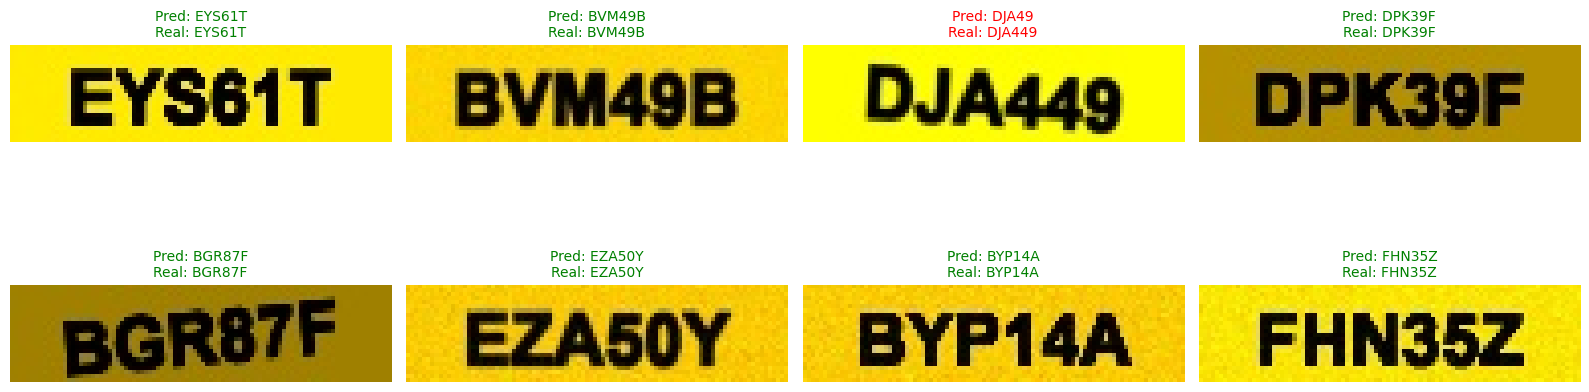

In [ ]:
# Visualizar predicciones
import matplotlib.pyplot as plt

model.eval()
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

with torch.no_grad():
    imgs, labels, lengths = next(iter(test_loader))
    imgs_device = imgs.to(device)
    outputs = model(imgs_device)

    label_offset = 0
    for i in range(8):
        ax = axes[i // 4, i % 4]

        # Imagen
        img = imgs[i].permute(1, 2, 0).numpy()
        img = (img * 0.5 + 0.5) * 255  # Desnormalizar
        img = img.astype('uint8')
        ax.imshow(img)

        # Predicción
        pred = decode_output(outputs[:, i, :])

        # Label real
        label_len = lengths[i].item()
        label_indices = labels[label_offset:label_offset + label_len].tolist()
        true_label = ''.join([CHARS[idx] for idx in label_indices])
        label_offset += label_len

        color = 'green' if pred == true_label else 'red'
        ax.set_title(f"Pred: {pred}\nReal: {true_label}", color=color, fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

---
## 8. Exportar a ONNX para Hailo

In [ ]:
# Instalar onnxscript para evitar ModuleNotFoundError
!pip install onnxscript -q

import onnx
import os

# Forzar exportador legacy de PyTorch (más compatible con Hailo)
os.environ["PYTORCH_ONNX_USE_LEGACY_EXPORTER"] = "1"

class LPRNetExport(nn.Module):
    """
    LPRNet para exportación a ONNX.
    Usa AvgPool2d fijo en lugar de AdaptiveAvgPool2d para mejor compatibilidad.
    """
    def __init__(self, num_classes=37):
        super().__init__()
        self.num_classes = num_classes

        self.backbone = nn.Sequential(
            # Stage 1: (B, 3, 24, 94) -> (B, 64, 24, 94)
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=(1, 1), padding=1),

            # Stage 2: (B, 64, 24, 94) -> (B, 128, 12, 47)
            SmallBasicBlock(64, 128, 3),
            nn.MaxPool2d(kernel_size=3, stride=(2, 2), padding=1),

            # Stage 3: (B, 128, 12, 47) -> (B, 256, 6, 24)
            SmallBasicBlock(128, 256, 3),
            SmallBasicBlock(256, 256, 3),
            nn.MaxPool2d(kernel_size=3, stride=(2, 2), padding=1),

            # Stage 4: (B, 256, 6, 24) -> (B, 256, 5, 24) after this Conv2d
            nn.Conv2d(256, 256, kernel_size=(4, 1), stride=1, padding=(1, 0)),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # Output of backbone: (B, num_classes, 5, 24) after this Conv2d
            nn.Conv2d(256, num_classes, kernel_size=(1, 13), stride=1, padding=(0, 6)),
            nn.BatchNorm2d(num_classes),
            nn.ReLU(inplace=True),
        )

        # AvgPool2d fijo en lugar de AdaptiveAvgPool2d
        # Input to avgpool is (B, num_classes, 5, 24), so kernel_size=(5, 1) is needed to reduce height to 1
        self.avgpool = nn.AvgPool2d(kernel_size=(5, 1), stride=1, padding=0)

    def forward(self, x):
        x = self.backbone(x)
        x = self.avgpool(x)   # (B, C, 1, W)
        x = x.squeeze(2)      # (B, C, W)
        x = x.permute(2, 0, 1)  # (W, B, C)
        return x


def export_to_onnx(weights_path, output_path):
    print(f"Loading model from {weights_path}")

    # Crear modelo de exportación
    model_export = LPRNetExport(num_classes=NUM_CLASSES)

    # Cargar pesos del modelo entrenado
    state_dict = torch.load(weights_path, map_location='cpu')

    # Remap state_dict keys for LPRNetExport
    new_state_dict = {}
    for k, v in state_dict.items():
        if 'backbone.9' in k: # This was Dropout in original, has no params, so skip.
            continue
        elif 'backbone.13' in k: # This was Dropout in original, has no params, so skip.
            continue
        elif 'backbone.10' in k: # Original Conv2d, now backbone.9 in LPRNetExport
            new_key = k.replace('backbone.10', 'backbone.9')
            new_state_dict[new_key] = v
        elif 'backbone.11' in k: # Original BatchNorm2d, now backbone.10 in LPRNetExport
            new_key = k.replace('backbone.11', 'backbone.10')
            new_state_dict[new_key] = v
        elif 'backbone.14' in k: # Original Conv2d, now backbone.12 in LPRNetExport
            new_key = k.replace('backbone.14', 'backbone.12')
            new_state_dict[new_key] = v
        elif 'backbone.15' in k: # Original BatchNorm2d, now backbone.13 in LPRNetExport
            new_key = k.replace('backbone.15', 'backbone.13')
            new_state_dict[new_key] = v
        else:
            new_state_dict[k] = v

    # Cargar pesos en el modelo de exportación con las claves remapeadas
    model_export.load_state_dict(new_state_dict, strict=True) # strict=True now that keys should match
    model_export.eval()

    # Verificar output shape
    dummy_input = torch.randn(1, 3, 24, 94)
    with torch.no_grad():
        output = model_export(dummy_input)
    print(f"Input shape: {dummy_input.shape}")
    print(f"Output shape: {output.shape}")

    # Exportar a ONNX
    print(f"Exporting to {output_path}")
    torch.onnx.export(
        model_export,
        dummy_input,
        output_path,
        export_params=True,
        opset_version=11,  # Hailo soporta bien opset 11
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes=None  # Fixed batch size
    )

    # Verificar
    print("Verifying ONNX model...")
    onnx_model = onnx.load(output_path)
    print(f"ONNX opset version: {onnx_model.opset_import[0].version}")
    onnx.checker.check_model(onnx_model)
    print("✅ ONNX model is valid!")

    # Simplificar
    try:
        import onnxsim
        print("Simplifying ONNX model...")
        model_simp, check = onnxsim.simplify(onnx_model)
        if check:
            onnx.save(model_simp, output_path)
            print("✅ ONNX model simplified!")
    except ImportError:
        print("⚠️ onnx-simplifier not installed")

    # Info
    print("\n📊 Model info:")
    onnx_model = onnx.load(output_path)
    for inp in onnx_model.graph.input:
        shape = [d.dim_value for d in inp.type.tensor_type.shape.dim]
        print(f"   Input: {inp.name} - {shape}")
    for out in onnx_model.graph.output:
        shape = [d.dim_value for d in out.type.tensor_type.shape.dim]
        print(f"   Output: {out.name} - {shape}")

    return output_path

# Exportar
onnx_path = export_to_onnx(
    os.path.join(SAVE_DIR, 'best_model.pth'),
    os.path.join(SAVE_DIR, 'lprnet_colombia.onnx')
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.0/683.0 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 8.6 MB/s eta 0:00:00
Loading model from /content/runs/lprnet_colombia/best_model.pth
Input shape: torch.Size([1, 3, 24, 94])
Output shape: torch.Size([24, 1, 37])
Exporting to /content/runs/lprnet_colombia/lprnet_colombia.onnx


W1216 15:25:08.957000 334 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `LPRNetExport([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LPRNetExport([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:68: adapter_lookup: Assertion `false`

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 15 of general pattern rewrite rules.
Verifying ONNX model...
ONNX opset version: 18
✅ ONNX model is valid!
⚠️ onnx-simplifier not installed

📊 Model info:
   Input: input - [1, 3, 24, 94]
   Output: output - [24, 1, 37]


In [ ]:
# Verificar con ONNX Runtime
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession(onnx_path)

# Test inference
test_input = np.random.randn(1, 3, 24, 94).astype(np.float32)
outputs = session.run(None, {session.get_inputs()[0].name: test_input})

print(f"ONNX Runtime output shape: {outputs[0].shape}")
print("✅ ONNX Runtime inference passed!")

ONNX Runtime output shape: (24, 1, 37)
✅ ONNX Runtime inference passed!


---
## 9. Descargar Modelo

In [ ]:
# Crear zip con todo
!cd /content/runs/lprnet_colombia && zip -r /content/lprnet_colombia_hailo.zip .

from google.colab import files
files.download('/content/lprnet_colombia_hailo.zip')

  adding: logs/ (stored 0%)
  adding: logs/events.out.tfevents.1765897863.3ba32ba5a00b.334.0 (deflated 71%)
  adding: final_model.pth (deflated 8%)
  adding: checkpoint_epoch100.pth (deflated 9%)
  adding: checkpoint_epoch350.pth (deflated 9%)
  adding: lprnet_colombia.onnx (deflated 84%)
  adding: checkpoint_epoch400.pth (deflated 9%)
  adding: checkpoint_epoch150.pth (deflated 9%)
  adding: best_model.pth (deflated 8%)
  adding: lprnet_colombia.onnx.data (deflated 7%)
  adding: checkpoint_epoch50.pth (deflated 9%)
  adding: checkpoint_epoch250.pth (deflated 9%)
  adding: checkpoint_epoch300.pth (deflated 9%)
  adding: checkpoint_epoch200.pth (deflated 9%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 10. Siguiente: Compilar a HEF

En tu máquina con Hailo DFC:

```bash
# 1. Parsear ONNX
hailo parser onnx lprnet_colombia.onnx

# 2. Optimizar (crear archivo .har)
hailo optimize lprnet_colombia.har \
    --calib-path /path/to/calibration_images/ \
    --hw-arch hailo8l

# 3. Compilar a HEF
hailo compiler lprnet_colombia_optimized.har
```

In [ ]:
# Celda 1: Instalar PyTorch 1.13
!pip uninstall torch torchvision torchaudio -y
!pip install torch==1.13.1 torchvision==0.14.1 --index-url https://download.pytorch.org/whl/cu117

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Looking in indexes: https://download.pytorch.org/whl/cu117
ERROR: Could not find a version that satisfies the requirement torch==1.13.1 (from versions: none)
ERROR: No matching distribution found for torch==1.13.1
